# trained vs untrained RSA

Run this notebook from the `assignment` folder using the project `.venv` kernel. It loads the saved trained weights and creates random untrained models


In [1]:
%matplotlib inline
from pathlib import Path
from itertools import combinations
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, t
from statsmodels.stats.multitest import multipletests
from torch.utils.data import DataLoader

from analysis import compute_rdm, analyze_model, load_trained_model
from core import SantoroDataset, MODEL_CLASSES

MODEL_DIR = Path("models")
RUNS = range(5)

dataset = SantoroDataset()
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
brain_rdm = compute_rdm(dataset.brain_responses.numpy())


## Analyse one architecture

This function creates five random versions and loads five trained versions of the requested architecture


In [2]:
def analyse_architecture(model_name):
    results = []

    for run in RUNS:
        torch.manual_seed(run)
        untrained_model = MODEL_CLASSES[model_name](num_classes=50)
        results += analyze_model(
            model_name, "untrained", untrained_model,
            dataloader, brain_rdm, run=run
        )

        weights_path = MODEL_DIR / f"{model_name}_run{run}_best.pt"
        trained_model = load_trained_model(model_name, weights_path)
        results += analyze_model(
            model_name, "trained", trained_model,
            dataloader, brain_rdm, run=run
        )

    return pd.DataFrame(results)


## Run all three architectures

These are the slow cells. Each one runs for each model, all its instances (5), and compares RDMs of models and brains. It is done for trained and untrained


In [3]:
waveform_df = analyse_architecture("waveform")
waveform_df.head()


,model,training,layer,run,layer_index,n_layers,relative_depth,rsa
0,waveform,untrained,hidden_layers.0,0,0,6,0.0,-0.024911
1,waveform,untrained,hidden_layers.1,0,1,6,0.2,-0.020895
2,waveform,untrained,hidden_layers.2,0,2,6,0.4,-0.040977
3,waveform,untrained,hidden_layers.3,0,3,6,0.6,-0.024275
4,waveform,untrained,hidden_layers.4,0,4,6,0.8,-0.003632


In [4]:
uninspired_df = analyse_architecture("uninspired")
uninspired_df.head()


,model,training,layer,run,layer_index,n_layers,relative_depth,rsa
0,uninspired,untrained,conv_layers.0,0,0,6,0.0,0.057983
1,uninspired,untrained,conv_layers.1,0,1,6,0.2,0.105535
2,uninspired,untrained,conv_layers.2,0,2,6,0.4,0.118768
3,uninspired,untrained,fc_layers.0,0,3,6,0.6,0.070742
4,uninspired,untrained,fc_layers.1,0,4,6,0.8,0.073063


In [5]:
inspired_df = analyse_architecture("inspired")
inspired_df.head()


KeyboardInterrupt: 

## Simple plots and comparisons

Pass any architecture DataFrame into the training or depth functions. Combine the three DataFrames for architecture comparisons.


In [ ]:
def run_scores(df):
    return df.groupby(["model", "training", "run"], as_index=False)["rsa"].mean()


def summary_with_ci(df, groups):
    summary = df.groupby(groups)["rsa"].agg(["mean", "sem", "count"]).reset_index()
    summary["ci95"] = t.ppf(0.975, summary["count"] - 1) * summary["sem"]
    return summary


def plot_training(df):
    scores = run_scores(df)
    summary = summary_with_ci(scores, ["model", "training"])
    models = summary["model"].unique()
    x = np.arange(len(models))

    fig, ax = plt.subplots(figsize=(7, 4))
    for offset, training, color in [(-0.15, "untrained", "gray"), (0.15, "trained", "tab:blue")]:
        part = summary[summary["training"] == training].set_index("model").loc[models]
        ax.errorbar(x + offset, part["mean"], yerr=part["ci95"],
                    fmt="o", capsize=5, label=training, color=color)
    low = (summary["mean"] - summary["ci95"]).min()
    high = (summary["mean"] + summary["ci95"]).max()
    padding = max((high - low) * 0.1, 0.01)
    ax.set_ylim(low - padding, high + padding)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xticks(x, models)
    ax.set_ylabel("Mean RSA across layers")
    ax.set_title("Trained vs untrained (95% CI)")
    ax.legend()
    plt.show()


def plot_depth(df):
    summary = summary_with_ci(df, ["model", "training", "layer", "layer_index"])
    models = summary["model"].unique()
    low = (summary["mean"] - summary["ci95"]).min()
    high = (summary["mean"] + summary["ci95"]).max()
    padding = max((high - low) * 0.1, 0.01)
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4),
                             squeeze=False, sharey=True)

    for ax, model_name in zip(axes[0], models):
        for training, color in [("untrained", "gray"), ("trained", "tab:blue")]:
            part = summary[(summary["model"] == model_name) & (summary["training"] == training)].sort_values("layer_index")
            layer_number = part["layer_index"] + 1
            ax.plot(layer_number, part["mean"], "o-", label=training, color=color)
            ax.fill_between(layer_number,
                            part["mean"] - part["ci95"],
                            part["mean"] + part["ci95"],
                            alpha=0.2, color=color)
        layers = summary[summary["model"] == model_name][["layer_index", "layer"]].drop_duplicates().sort_values("layer_index")
        names = layers["layer"].map(
            lambda name: "hidden" if name.startswith("hidden")
            else "conv" if name.startswith("conv")
            else "fully connected" if name.startswith("fc")
            else "output" if name == "classifier"
            else name
        )
        numbers = layers["layer_index"] + 1
        ax.set_xticks(numbers, [f"{number}\n{name}" for number, name in zip(numbers, names)])
        for label in ax.get_xticklabels():
            label.set_rotation(25)
            label.set_ha("right")
            label.set_fontstyle("italic")
        ax.set_ylim(low - padding, high + padding)
        ax.axhline(0, color="black", linewidth=0.7)
        ax.set_title(model_name)
        ax.set_xlabel("Model layer")
        ax.legend()
    axes[0, 0].set_ylabel("RSA with STG (95% CI)")
    plt.tight_layout()
    plt.show()



def add_holm_correction(table):
    table["p_holm"] = multipletests(table["p_value"], method="holm")[1]
    table["significant"] = table["p_holm"] < 0.05
    return table


def compare_training(df):
    scores = run_scores(df)
    rows = []
    for model_name in scores["model"].unique():
        trained = scores[(scores["model"] == model_name) & (scores["training"] == "trained")]["rsa"]
        untrained = scores[(scores["model"] == model_name) & (scores["training"] == "untrained")]["rsa"]
        test = ttest_ind(trained, untrained, equal_var=False)
        rows.append({
            "model": model_name,
            "trained_mean": trained.mean(),
            "untrained_mean": untrained.mean(),
            "difference": trained.mean() - untrained.mean(),
            "p_value": test.pvalue,
        })
    return add_holm_correction(pd.DataFrame(rows))


def compare_architectures(df):
    trained = run_scores(df)
    trained = trained[trained["training"] == "trained"]
    rows = []
    for first, second in combinations(trained["model"].unique(), 2):
        first_scores = trained[trained["model"] == first]["rsa"]
        second_scores = trained[trained["model"] == second]["rsa"]
        test = ttest_ind(first_scores, second_scores, equal_var=False)
        rows.append({
            "comparison": f"{first} vs {second}",
            "difference": first_scores.mean() - second_scores.mean(),
            "p_value": test.pvalue,
        })
    return add_holm_correction(pd.DataFrame(rows))


## 95% confidence bands and error bars

The dots and lines are the mean across five runs. The shaded area and error bars are the 95% confidence interval. It shows how much the answer changes between runs. Wide means less stable. Narrow means more stable.

We only have five runs so we use the Student t value 2.776 instead of 1.96. Five is a small sample so the honest interval is wider. This interval only covers model runs. It does not cover different people because the brain data is from one person.


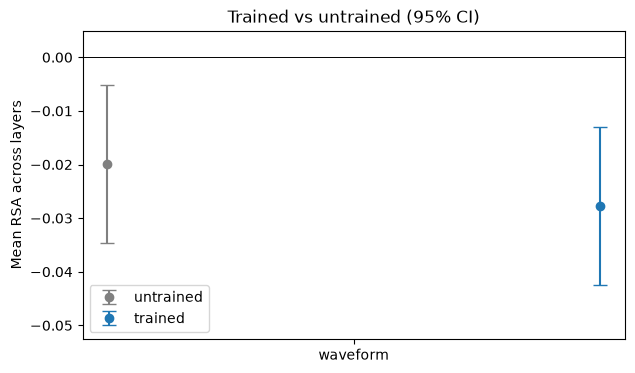

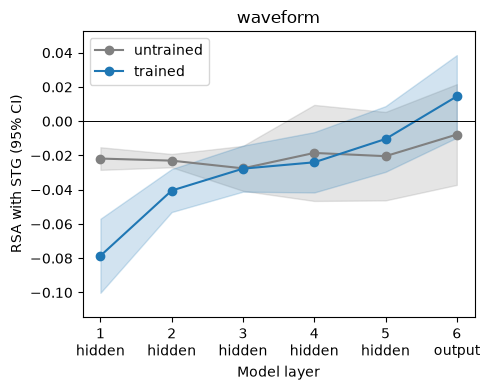

,model,trained_mean,untrained_mean,difference,p_value,p_holm,significant
0,waveform,-0.027764,-0.019833,-0.007932,0.322038,0.322038,False


In [ ]:
plot_training(waveform_df)
plot_depth(waveform_df)
compare_training(waveform_df)


## Compare all three architectures

The layer plots use one shared vertical scale. Each x axis shows layer 1 2 3 and so on with the real layer type written below it. This makes the models easier to compare even though Inspired has five measured layers and the others have six.


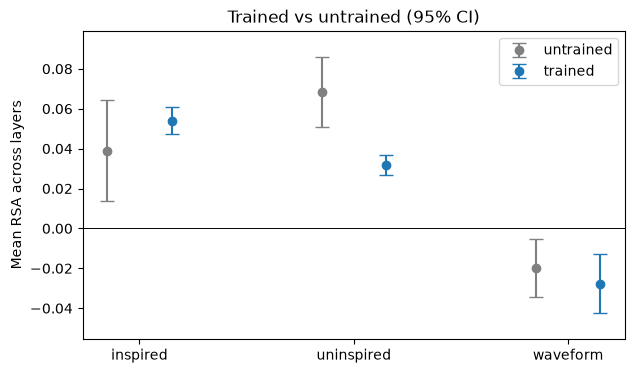

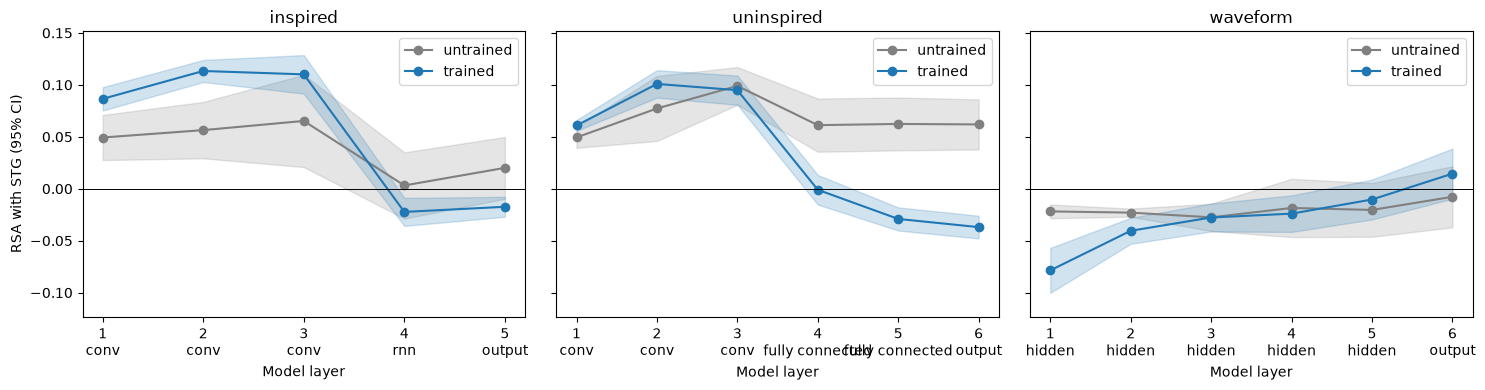

,model,trained_mean,untrained_mean,difference,p_value,p_holm,significant
0,inspired,0.054058,0.038848,0.015210,0.173592,0.347183,False
1,uninspired,0.031607,0.068520,-0.036913,0.003170,0.009511,True
2,waveform,-0.027764,-0.019833,-0.007932,0.322038,0.347183,False


,comparison,difference,p_value,p_holm,significant
0,inspired vs uninspired,0.022451,0.000128,0.000255,True
1,inspired vs waveform,0.081822,0.000014,0.000041,True
2,uninspired vs waveform,0.059371,0.000148,0.000255,True


In [ ]:
all_df = pd.concat([waveform_df, uninspired_df, inspired_df], ignore_index=True)

plot_training(all_df)
plot_depth(all_df)
display(compare_training(all_df))
display(compare_architectures(all_df))


### What the layer graph suggests

Waveform is weak at every layer. It gets a little better near the output but stays close to zero.

Uninspired and Inspired match STG best in their convolution layers. Their scores fall when they reach the fully connected or recurrent part. Convolution layers keep simple sound patterns such as frequency and timing. STG also reacts to this kind of sound structure so the RDMs can line up.

Convolution layers work well here because they read small patterns in a spectrogram. They can pick up frequency bands changes over time and short sound events. Auditory cortex also responds to frequency and timing patterns so this is a better match than feeding in the raw waveform with no sound structure. The later fully connected recurrent and output layers combine or remove these details to solve ESC-50 classification. That can make them less similar to STG even when classification gets better.




t-SNE Analysis

waveform: untrained, hidden_layers.4
waveform: trained, hidden_layers.4
uninspired: untrained, fc_layers.1
uninspired: trained, fc_layers.1
inspired: untrained, rnn
inspired: trained, rnn


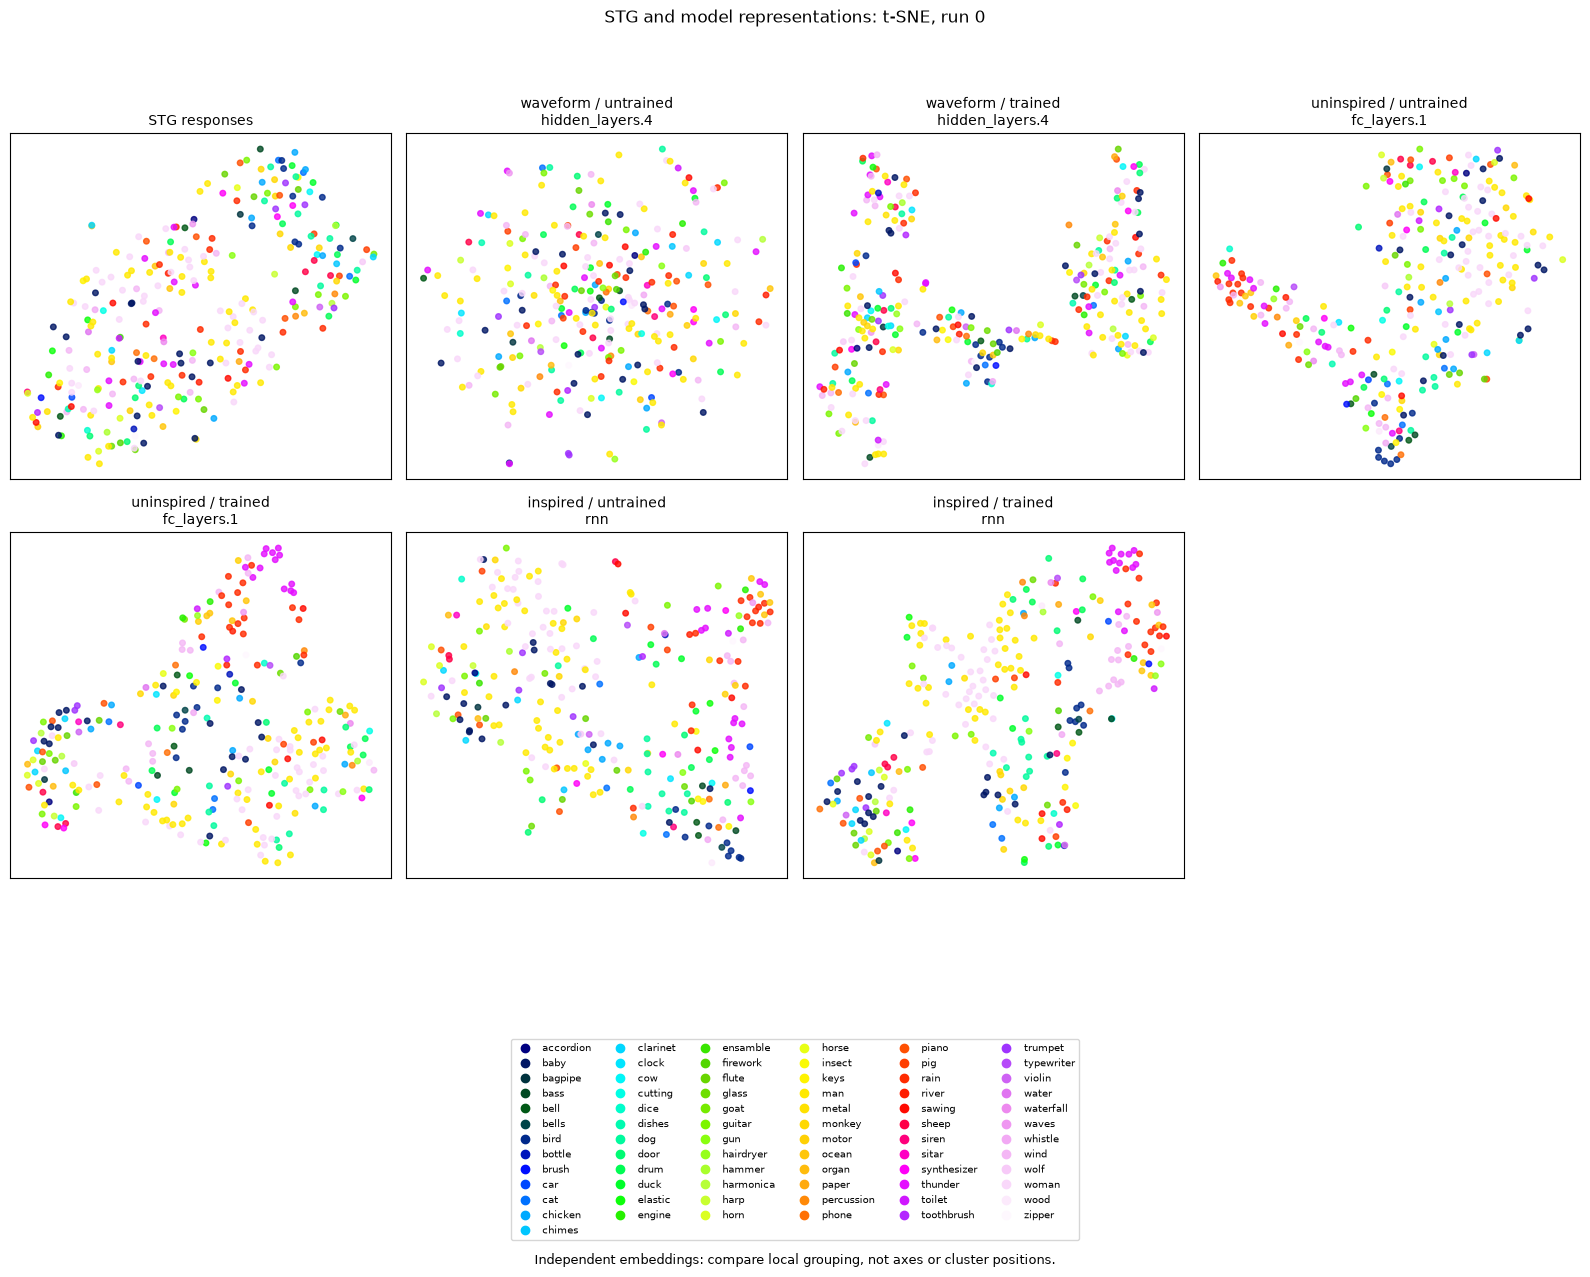

Saved img\tsne_run0.png


In [6]:

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
from core import extract_activations

TSNE_RUN = 0
SELECTED_LAYERS = {
    "waveform": "hidden_layers.4",
    "uninspired": "fc_layers.1",
    "inspired": "rnn",
}


def tsne_embedding(patterns):
    patterns = np.asarray(patterns).reshape(len(dataset), -1)

    reduced = PCA(
        n_components=min(50, len(dataset) - 1, patterns.shape[1]),
        svd_solver="randomized",
        random_state=42,
    ).fit_transform(patterns)

    return TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=42,
    ).fit_transform(reduced)


# Brain responses and model activations use the same sound order.
panels = [
    ("STG responses", tsne_embedding(dataset.brain_responses.numpy()))
]

for model_name, layer in SELECTED_LAYERS.items():
    for training in ("untrained", "trained"):
        print(f"{model_name}: {training}, {layer}")

        if training == "untrained":
            torch.manual_seed(TSNE_RUN)
            model = MODEL_CLASSES[model_name](num_classes=50)
        else:
            model = load_trained_model(
                model_name,
                MODEL_DIR / f"{model_name}_run{TSNE_RUN}_best.pt",
            )

        activations = extract_activations(dataloader, model)
        coordinates = tsne_embedding(activations[layer].numpy())
        panels.append(
            (f"{model_name} / {training}\n{layer}", coordinates)
        )
        del activations, model

# Consistent category colors across every panel.
categories = np.asarray(dataset.categories)
category_names = sorted(set(categories))
cmap = plt.get_cmap("gist_ncar")
colors = {
    name: cmap(i / max(1, len(category_names) - 1))
    for i, name in enumerate(category_names)
}

fig, axes = plt.subplots(2, 4, figsize=(16, 13))

for ax, (title, coordinates) in zip(axes.flat, panels):
    ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=[colors[category] for category in categories],
        s=16,
        alpha=0.8,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

axes.flat[-1].axis("off")

fig.suptitle(
    f"STG and model representations: t-SNE, run {TSNE_RUN}"
)
fig.legend(
    handles=[
        Line2D(
            [], [], marker="o", linestyle="",
            color=color, label=name,
        )
        for name, color in colors.items()
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=6,
    fontsize=7,
)
fig.text(
    0.5, 0.015,
    "Independent embeddings: compare local grouping, "
    "not axes or cluster positions.",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=(0, 0.30, 1, 0.95))

image_dir = MODEL_DIR.parent / "img"
image_dir.mkdir(exist_ok=True)
image_path = image_dir / f"tsne_run{TSNE_RUN}.png"

fig.savefig(image_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved {image_path}")



TSNE EXPLANATION
We used t-SNE to visualize how the models group sounds, as requested in the assignment. Each dot represents one sound, and its color indicates the sound category. Nearby dots suggest similar representations locally. This helps us see how training changes the organization of sounds alongside the numerical RSA results.

In the run-0 plots, the untrained WaveformModel formed a relatively spread-out cloud, while its trained version showed more distinct groups. Training also changed the grouping in InspiredModel and UninspiredModel. However, many groups still contained several categories, and the STG plot also showed overlapping categories.

These results show that clearer-looking groups do not necessarily mean better brain alignment. The trained models developed visible structure even where their selected layers had weak RSA scores. Therefore, t-SNE helps illustrate changes in sound representations, while RSA measures their correspondence with STG. Because the plots were fitted separately and show only one run and selected layers, we cannot use their shapes or cluster positions to rank the models’ brain alignment
